Step 1 — Import Libraries

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt

Step 2 — Load and Preprocess Image

In [2]:
# Function to load and preprocess image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),

        # Normalize using ImageNet stats
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    image = Image.open(image_path).convert('RGB')
    image = transform(image)

    # Add batch dimension → (1, 3, 224, 224)
    image = image.unsqueeze(0)

    return image

Step 3 — Load Pretrained Models

In [3]:
# Load models
vgg16 = models.vgg16(pretrained=True)
resnet50 = models.resnet50(pretrained=True)

# Set to evaluation mode
vgg16.eval()
resnet50.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 100MB/s] 
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Step 4 — Prediction Function (Top-5)

In [7]:
# Load ImageNet labels
with open("imagenet_classes.txt") as f:
    labels = [line.strip() for line in f.readlines()]

# Prediction function
def predict(model, image):
    with torch.no_grad():
        outputs = model(image)

        # Convert to probabilities
        probs = torch.nn.functional.softmax(outputs[0], dim=0)

        # Top 5 predictions
        top5_prob, top5_catid = torch.topk(probs, 5)

        results = []
        for i in range(5):
            results.append((labels[top5_catid[i]], top5_prob[i].item()))

    return results

In [8]:
import requests

# URL for ImageNet class labels
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"

# Download the file
response = requests.get(url)
with open("imagenet_classes.txt", "w") as f:
    f.write(response.text)

print("imagenet_classes.txt downloaded successfully.")

imagenet_classes.txt downloaded successfully.


Step 5 — Image Path + Preprocessing

In [9]:
image_path = "DP.jpeg"  # change this

image = preprocess_image(image_path)

Step 6 — Run Predictions

In [10]:
print("VGG16 Predictions:")
for label, prob in predict(vgg16, image):
    print(f"{label}: {prob:.4f}")

print("\nResNet50 Predictions:")
for label, prob in predict(resnet50, image):
    print(f"{label}: {prob:.4f}")

VGG16 Predictions:
academic gown: 0.2361
suit: 0.1476
trench coat: 0.1219
mortarboard: 0.0788
cloak: 0.0729

ResNet50 Predictions:
comic book: 0.2101
suit: 0.0942
velvet: 0.0557
ski mask: 0.0408
neck brace: 0.0381


Visualization

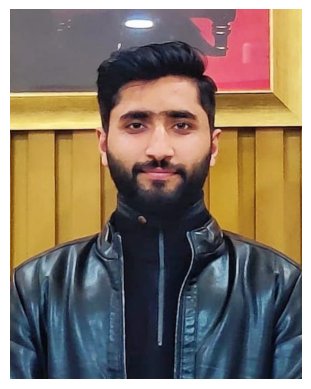

In [11]:
def show_image(image_path):
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

show_image(image_path)

TASK 1 (AlexNet)

In [12]:
alexnet = models.alexnet(pretrained=True)
alexnet.eval()

print("\nAlexNet Predictions:")
for label, prob in predict(alexnet, image):
    print(f"{label}: {prob:.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 182MB/s]



AlexNet Predictions:
suit: 0.0785
cowboy hat: 0.0731
sombrero: 0.0536
academic gown: 0.0503
gasmask: 0.0440


ResNet

In [13]:
resnet101 = models.resnet101(pretrained=True)
resnet101.eval()

print("\nResNet101 Predictions:")
for label, prob in predict(resnet101, image):
    print(f"{label}: {prob:.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:00<00:00, 179MB/s]



ResNet101 Predictions:
bulletproof vest: 0.2086
comic book: 0.2037
academic gown: 0.1788
neck brace: 0.0434
mortarboard: 0.0362


MobileNet

In [14]:
mobilenet = models.mobilenet_v2(pretrained=True)
mobilenet.eval()

print("\nMobileNet Predictions:")
for label, prob in predict(mobilenet, image):
    print(f"{label}: {prob:.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 161MB/s]



MobileNet Predictions:
trench coat: 0.1769
suit: 0.1549
prison: 0.1099
bulletproof vest: 0.0583
academic gown: 0.0549


TASK 2

Transfer Learning

In [1]:
!pip install roboflow

In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="2yhE0XoVP8VjERSiNyya")
project = rf.workspace("mubashar-workspace-nd2nw").project("wildfire-vxrin-sende")
version = project.version(1)

dataset = version.download("yolov11")   # your format

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to wildfire-1 in yolov11:: 100%|██████████| 1439/1439 [00:00<00:00, 3544.12it/s]


Step 1 — Convert YOLO Dataset → Classification Format

In [7]:
import os
import shutil

base_path = dataset.location

# Create classification folders
os.makedirs("data/train/fire", exist_ok=True)
os.makedirs("data/train/no_fire", exist_ok=True)

# Function to convert YOLO → classification
def convert_split(split):
    img_dir = os.path.join(base_path, split, "images")
    label_dir = os.path.join(base_path, split, "labels")

    # Clear directories before copying to avoid duplicate files if cell is run multiple times
    shutil.rmtree("data/train/fire", ignore_errors=True)
    shutil.rmtree("data/train/no_fire", ignore_errors=True)
    os.makedirs("data/train/fire", exist_ok=True)
    os.makedirs("data/train/no_fire", exist_ok=True)

    for img_name in os.listdir(img_dir):
        img_path = os.path.join(img_dir, img_name)
        # Assuming label files have the same name as images but with .txt extension
        # and are in the 'labels' directory
        label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))

        # If label file exists and NOT empty → fire
        # Otherwise → no_fire
        if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
            shutil.copy(img_path, f"data/train/fire/{img_name}")
        else:
            shutil.copy(img_path, f"data/train/no_fire/{img_name}")

# Convert train split
convert_split("train")

# --- Added fix: Remove empty class directories ---
# Check and remove empty class directories to prevent ImageFolder errors
if not os.listdir("data/train/fire"): # If 'fire' directory is empty
    os.rmdir("data/train/fire")
    print("Removed empty 'data/train/fire' directory. No 'fire' instances found for training.")
if not os.listdir("data/train/no_fire"): # If 'no_fire' directory is empty
    os.rmdir("data/train/no_fire")
    print("Removed empty 'data/train/no_fire' directory. No 'no_fire' instances found for training.")
# --- End added fix ---

print("Conversion Done ✅")

Removed empty 'data/train/no_fire' directory. No 'no_fire' instances found for training.
Conversion Done ✅


Step 2 — Load Dataset (PyTorch)

In [8]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
}

train_data = datasets.ImageFolder("data/train", transform=data_transforms['train'])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

print("Classes:", train_data.classes)

Classes: ['fire']


Step 3 — Load ResNet50 (Transfer Learning)

In [9]:
from torchvision import models

model = models.resnet50(pretrained=True)

# Freeze layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
num_classes = len(train_data.classes)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.


Step 4 — Training Setup

In [10]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

Step 5 — Training Loop

In [11]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.0000
Epoch 2, Loss: 0.0000
Epoch 3, Loss: 0.0000
Epoch 4, Loss: 0.0000
Epoch 5, Loss: 0.0000


Step 6 — Test on Image

In [15]:
import os

# Get a list of files in the 'fire' directory
fire_images = os.listdir("data/train/fire")

# Check if there are any images
if fire_images:
    # Take the first image found as a sample
    sample_image_name = fire_images[0]
    sample_image_path = os.path.join("data/train/fire", sample_image_name)
    print(f"Using sample image: {sample_image_path}")
else:
    sample_image_path = None
    print("No images found in data/train/fire to use as a sample.")


Using sample image: data/train/fire/fire-32_png.rf.b857085e819cb3024359b3daabc18a52.jpg


fire


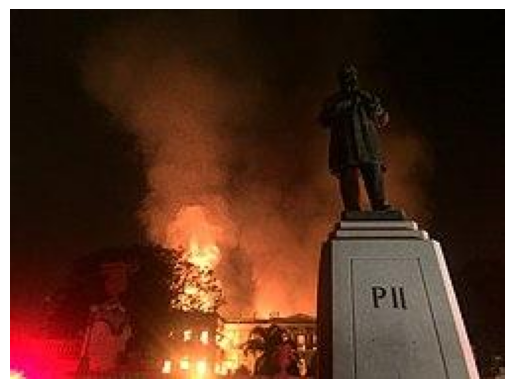

In [18]:
from PIL import Image
import matplotlib.pyplot as plt

def show_image(image_path):
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

def predict_fire(image_path):
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        _, pred = torch.max(outputs, 1)

    return train_data.classes[pred.item()]

# Example
if sample_image_path:
    print(predict_fire(sample_image_path))
    show_image(sample_image_path)
else:
    print("Cannot predict: No sample image path available.")